In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pymn
import anndata as ad

In [3]:
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# Color-blind-friendly AUROC colormap:
# 0 = blue, 0.5 = gray, 1 = vermillion/orange
blue_gray_orange = LinearSegmentedColormap.from_list(
    "blue_gray_orange",
    [
        (0.0, "#0072B2"),
        (0.5, "#D9D9D9"),
        (1.0, "#D55E00"),
    ],
)


def metaneighbor_style_auroc(
    query_adata,
    target_adata,
    query_groupby,
    target_groupby,
    query_layer=None,
    target_layer=None,
    min_cells=10,
    n_variable_genes=200,
    correlation_method="spearman",
    vmin=0.5,
    vmax=0.8,
    cmap="viridis",
    x_order=None,
    y_order=None,
    figsize=(12, 8),
    save_prefix="metaneighbor_style_AUROC",
    plot=True,
    verbose=True,
):
    """
    MetaNeighbor-style AUROC comparing query groups to target groups.

    Parameters
    ----------
    query_adata : AnnData
        Dataset used to construct query-group pseudobulk profiles.
    target_adata : AnnData
        Dataset containing target cells to classify.
    query_groupby : str
        obs column defining query groups.
    target_groupby : str
        obs column defining target groups.
    query_layer : str or None
        Layer used for query pseudobulk profiles.
        If None, query_adata.X is used.
    target_layer : str or None
        Layer used for target pseudobulk profiles and target cell scoring.
        If None, target_adata.X is used.
    min_cells : int
        Minimum number of cells required per group.
    n_variable_genes : int
        Number of variable genes selected independently from each dataset
        before taking their intersection.
    correlation_method : {"spearman", "pearson"}
        Correlation used to score target cells against query profiles.
    x_order : list or None
        Desired target-group order on the x-axis.
    y_order : list or None
        Desired query-group order on the y-axis.
    """

    def get_expression_matrix(adata, layer, dataset_name):
        if layer is None:
            return adata.X

        if layer not in adata.layers:
            raise KeyError(
                f"Layer '{layer}' not found in {dataset_name}. "
                f"Available layers: {list(adata.layers.keys())}"
            )

        return adata.layers[layer]

    def pseudobulk_mean_light(
        adata,
        groupby,
        genes,
        min_cells=5,
        layer=None,
        dataset_name="adata",
    ):
        groups = adata.obs[groupby].astype(str)

        valid = ~groups.isin(
            ["nan", "None", "NA", "Other"]
        )

        adata_view = adata[valid, genes]
        groups = adata_view.obs[groupby].astype(str)

        X = get_expression_matrix(
            adata_view,
            layer,
            dataset_name,
        )

        rows = []
        names = []
        ns = {}

        for group in sorted(groups.unique()):
            idx = np.where(groups.values == group)[0]

            if len(idx) < min_cells:
                continue

            X_group = X[idx, :]

            mean_expr = np.asarray(
                X_group.mean(axis=0)
            ).ravel()

            rows.append(mean_expr)
            names.append(group)
            ns[group] = len(idx)

        pseudobulk = pd.DataFrame(
            rows,
            index=names,
            columns=genes,
        )

        n_cells = pd.Series(
            ns,
            name="n_cells",
        )

        return pseudobulk, n_cells

    def score_cells_against_profile(
        X,
        profile,
        method="spearman",
    ):
        """
        Correlate every target cell against one query pseudobulk profile.
        """
        X = np.asarray(X, dtype=float)
        profile = np.asarray(profile, dtype=float)

        valid_genes = np.isfinite(profile)

        X = X[:, valid_genes]
        profile = profile[valid_genes]

        if method == "spearman":
            X_rank = np.apply_along_axis(
                rankdata,
                1,
                X,
            )

            profile_rank = rankdata(profile)

            X_centered = (
                X_rank
                - X_rank.mean(
                    axis=1,
                    keepdims=True,
                )
            )

            profile_centered = (
                profile_rank
                - profile_rank.mean()
            )

        elif method == "pearson":
            X_centered = (
                X
                - X.mean(
                    axis=1,
                    keepdims=True,
                )
            )

            profile_centered = (
                profile
                - profile.mean()
            )

        else:
            raise ValueError(
                "correlation_method must be "
                "'spearman' or 'pearson'"
            )

        numerator = (
            X_centered
            @ profile_centered
        )

        denominator = (
            np.sqrt(
                (X_centered ** 2).sum(axis=1)
            )
            * np.sqrt(
                (profile_centered ** 2).sum()
            )
        )

        with np.errstate(
            divide="ignore",
            invalid="ignore",
        ):
            scores = numerator / denominator

        scores[~np.isfinite(scores)] = np.nan

        return scores

    # -----------------------------
    # 1. Validate inputs
    # -----------------------------
    if query_groupby not in query_adata.obs.columns:
        raise KeyError(
            f"'{query_groupby}' not found in query_adata.obs"
        )

    if target_groupby not in target_adata.obs.columns:
        raise KeyError(
            f"'{target_groupby}' not found in target_adata.obs"
        )

    if query_layer is not None:
        if query_layer not in query_adata.layers:
            raise KeyError(
                f"Layer '{query_layer}' not found in query_adata. "
                f"Available layers: "
                f"{list(query_adata.layers.keys())}"
            )

    if target_layer is not None:
        if target_layer not in target_adata.layers:
            raise KeyError(
                f"Layer '{target_layer}' not found in target_adata. "
                f"Available layers: "
                f"{list(target_adata.layers.keys())}"
            )

    if verbose:
        print(
            "Query expression source:",
            ".X" if query_layer is None else query_layer,
        )

        print(
            "Target expression source:",
            ".X" if target_layer is None else target_layer,
        )

    # -----------------------------
    # 2. Shared genes
    # -----------------------------
    shared_genes = list(
        query_adata.var_names.intersection(
            target_adata.var_names
        )
    )

    if verbose:
        print(f"{len(shared_genes)} shared genes")

    if len(shared_genes) < 5:
        raise ValueError("Too few shared genes.")

    # -----------------------------
    # 3. Pseudobulk profiles
    # -----------------------------
    query_pb, query_n = pseudobulk_mean_light(
        query_adata,
        query_groupby,
        shared_genes,
        min_cells=min_cells,
        layer=query_layer,
        dataset_name="query_adata",
    )

    target_pb, target_n = pseudobulk_mean_light(
        target_adata,
        target_groupby,
        shared_genes,
        min_cells=min_cells,
        layer=target_layer,
        dataset_name="target_adata",
    )

    if query_pb.empty:
        raise ValueError(
            "No query groups passed the minimum cell threshold."
        )

    if target_pb.empty:
        raise ValueError(
            "No target groups passed the minimum cell threshold."
        )

    if verbose:
        print("\nQuery groups:")
        display(query_n)

        print("\nTarget groups:")
        display(target_n)

    # -----------------------------
    # 4. Shared variable genes
    # -----------------------------
    query_gene_var = query_pb.var(axis=0)
    target_gene_var = target_pb.var(axis=0)

    query_variable_genes = (
        query_gene_var
        .sort_values(ascending=False)
        .head(n_variable_genes)
        .index
        .tolist()
    )

    target_variable_genes = (
        target_gene_var
        .sort_values(ascending=False)
        .head(n_variable_genes)
        .index
        .tolist()
    )

    variable_genes = sorted(
        set(query_variable_genes).intersection(
            target_variable_genes
        )
    )

    if verbose:
        print(
            f"\nShared variable genes: "
            f"{len(variable_genes)}"
        )
        print(variable_genes)

    if len(variable_genes) < 5:
        raise ValueError(
            "Too few shared variable genes. "
            "Increase n_variable_genes."
        )

    query_pb_var = query_pb[variable_genes]

    # -----------------------------
    # 5. Prepare target cells
    # -----------------------------
    target_groups = (
        target_adata.obs[target_groupby]
        .astype(str)
    )

    valid_target = ~target_groups.isin(
        ["nan", "None", "NA", "Other"]
    )

    target_valid = target_adata[
        valid_target,
        variable_genes,
    ]

    target_labels = (
        target_valid.obs[target_groupby]
        .astype(str)
    )

    label_counts = target_labels.value_counts()

    keep_labels = (
        label_counts[
            label_counts >= min_cells
        ]
        .index
        .tolist()
    )

    if len(keep_labels) < 2:
        raise ValueError(
            "At least two target groups are required "
            "to calculate AUROC."
        )

    keep_cells = target_labels.isin(keep_labels)

    target_valid = target_valid[
        keep_cells,
        variable_genes,
    ]

    target_labels = (
        target_valid.obs[target_groupby]
        .astype(str)
    )

    X_target = get_expression_matrix(
        target_valid,
        target_layer,
        "target_adata",
    )

    if sparse.issparse(X_target):
        X_target = X_target.toarray()
    else:
        X_target = np.asarray(X_target)

    if verbose:
        print(
            f"\nTarget cells used: "
            f"{X_target.shape[0]}"
        )

        print(
            f"Genes used: "
            f"{X_target.shape[1]}"
        )

    # -----------------------------
    # 6. AUROC matrix
    # -----------------------------
    auroc = pd.DataFrame(
        index=query_pb_var.index,
        columns=keep_labels,
        dtype=float,
    )

    for query_group in query_pb_var.index:
        query_profile = (
            query_pb_var
            .loc[query_group]
            .values
        )

        scores = score_cells_against_profile(
            X_target,
            query_profile,
            method=correlation_method,
        )

        valid_scores = np.isfinite(scores)

        for target_group in keep_labels:
            y_true = (
                target_labels.values
                == target_group
            ).astype(int)

            y_valid = y_true[valid_scores]
            scores_valid = scores[valid_scores]

            if y_valid.sum() < min_cells:
                auroc.loc[
                    query_group,
                    target_group,
                ] = np.nan
                continue

            if y_valid.sum() == 0:
                auroc.loc[
                    query_group,
                    target_group,
                ] = np.nan
                continue

            if y_valid.sum() == len(y_valid):
                auroc.loc[
                    query_group,
                    target_group,
                ] = np.nan
                continue

            auroc.loc[
                query_group,
                target_group,
            ] = roc_auc_score(
                y_valid,
                scores_valid,
            )

    # -----------------------------
    # 7. Set y-axis order
    # -----------------------------
    if y_order is not None:
        missing_y = [
            group
            for group in y_order
            if group not in auroc.index
        ]

        if missing_y and verbose:
            print(
                "y_order groups not found and omitted:",
                missing_y,
            )

        valid_y_order = [
            group
            for group in y_order
            if group in auroc.index
        ]

        auroc = auroc.reindex(
            index=valid_y_order
        )

    elif isinstance(
        query_adata.obs[query_groupby].dtype,
        pd.CategoricalDtype,
    ):
        query_order = list(
            query_adata.obs[
                query_groupby
            ].cat.categories
        )

        query_order = [
            group
            for group in query_order
            if group in auroc.index
        ]

        auroc = auroc.reindex(
            index=query_order
        )

    # -----------------------------
    # 8. Set x-axis order
    # -----------------------------
    if x_order is not None:
        missing_x = [
            group
            for group in x_order
            if group not in auroc.columns
        ]

        if missing_x and verbose:
            print(
                "x_order groups not found and omitted:",
                missing_x,
            )

        valid_x_order = [
            group
            for group in x_order
            if group in auroc.columns
        ]

        auroc = auroc.reindex(
            columns=valid_x_order
        )

    elif isinstance(
        target_adata.obs[target_groupby].dtype,
        pd.CategoricalDtype,
    ):
        target_order = list(
            target_adata.obs[
                target_groupby
            ].cat.categories
        )

        target_order = [
            group
            for group in target_order
            if group in auroc.columns
        ]

        auroc = auroc.reindex(
            columns=target_order
        )

    if verbose:
        display(auroc)

    # -----------------------------
    # 9. Plot
    # -----------------------------
    if plot:
        fig, ax = plt.subplots(
            figsize=figsize
        )

        sns.heatmap(
            auroc,
            cmap=cmap,
            linewidths=0.5,
            linecolor="white",
            annot=False,
            vmin=vmin,
            vmax=vmax,
            ax=ax,
        )

        ax.set_xlabel(target_groupby)
        ax.set_ylabel(query_groupby)

        ax.set_title(
            f"MetaNeighbor-style AUROC: "
            f"{query_groupby} vs {target_groupby}"
        )

        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha="right",
        )

        plt.setp(
            ax.get_yticklabels(),
            rotation=0,
        )

        fig.tight_layout()

        if save_prefix is not None:
            fig.savefig(
                f"{save_prefix}.pdf",
                dpi=300,
                bbox_inches="tight",
            )

            fig.savefig(
                f"{save_prefix}.svg",
                bbox_inches="tight",
            )

        plt.show()

    return (
        auroc,
        variable_genes,
        query_n,
        target_n,
    )

In [4]:
def pseudobulk_correlation_heatmap(
    query_adata,
    target_adata,
    query_groupby,
    target_groupby,
    *,
    layer="lognorm",
    min_cells=10,
    n_variable_genes=300,
    gene_selection="combined",
    exclude_groups=("nan", "None", "NA", "Other"),
    method="pearson",
    cmap="coolwarm",
    vmin=None,
    vmax=None,
    figsize=(8, 8),
    save_prefix=None,
):
    def get_X(adata, genes):
        ad = adata[:, genes]
        X = ad.layers[layer] if layer is not None else ad.X
        return X.toarray() if sparse.issparse(X) else np.asarray(X)

    def pb(adata, groupby, genes):
        groups = adata.obs[groupby].astype(str)
        keep = ~groups.isin(exclude_groups)

        ad = adata[keep, genes].copy()
        groups = ad.obs[groupby].astype(str)

        rows = []
        names = []

        for g in sorted(groups.unique()):
            idx = np.where(groups.values == g)[0]
            if len(idx) < min_cells:
                continue

            X = get_X(ad, genes)[idx]
            rows.append(X.mean(axis=0))
            names.append(g)

        return pd.DataFrame(rows, index=names, columns=genes)

    genes = list(query_adata.var_names.intersection(target_adata.var_names))

    qpb_all = pb(query_adata, query_groupby, genes)
    tpb_all = pb(target_adata, target_groupby, genes)

    if gene_selection == "all":
        use_genes = genes
    else:
        combined = pd.concat([qpb_all, tpb_all], axis=0)
        use_genes = (
            combined.var(axis=0)
            .sort_values(ascending=False)
            .head(n_variable_genes)
            .index
            .tolist()
        )

    qpb = qpb_all[use_genes]
    tpb = tpb_all[use_genes]

    if method == "spearman":
        qpb = qpb.rank(axis=1)
        tpb = tpb.rank(axis=1)

    # correlation rows query x target
    q = qpb.sub(qpb.mean(axis=1), axis=0)
    t = tpb.sub(tpb.mean(axis=1), axis=0)

    corr = pd.DataFrame(
        q.values @ t.values.T /
        np.outer(
            np.sqrt((q.values ** 2).sum(axis=1)),
            np.sqrt((t.values ** 2).sum(axis=1))
        ),
        index=qpb.index,
        columns=tpb.index
    )

    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["svg.fonttype"] = "none"
    plt.rcParams["pdf.fonttype"] = 42

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        annot=True,
        fmt=".2f",
        linewidths=0,
        ax=ax
    )

    ax.set_xlabel(target_groupby)
    ax.set_ylabel(query_groupby)
    ax.set_title(f"Pseudobulk correlation: {query_groupby} vs {target_groupby}")
    plt.tight_layout()

    if save_prefix is not None:
        fig.savefig(f"{save_prefix}.svg", bbox_inches="tight", dpi=600)
        fig.savefig(f"{save_prefix}.pdf", bbox_inches="tight", dpi=600)

    plt.show()

    return corr, use_genes

In [5]:
URL = sc.read_h5ad("../../URL.h5ad")

In [6]:
URL.obs['med_2p_branch_full_ordered']

E9.5_GFP.data_AACCTGAGTGTTCCTC-1            Midbrain-fated Cells
E9.5_GFP.data_AACGAAAAGGTCCGAA-1            Midbrain-fated Cells
E9.5_GFP.data_AAGTGAACACGCGCAT-1            Midbrain-fated Cells
E9.5_GFP.data_AATGAAGCAAACAGGC-1            Midbrain-fated Cells
E9.5_GFP.data_AATGACCAGTTACGTC-1            Midbrain-fated Cells
                                                    ...         
E16.5_GFPTd_rep2.data_TTTGGAGTCGCGGTAC-1      Granule Cells+UBCs
E16.5_GFPTd_rep2.data_TTTGGTTAGCTGACAG-1                      RL
E16.5_GFPTd_rep2.data_TTTGGTTGTCAGTCTA-1      Granule Cells+UBCs
E16.5_GFPTd_rep2.data_TTTGTTGGTCTAATCG-1                      RL
E16.5_GFPTd_rep2.data_TTTGTTGTCTAGCATG-1      Granule Cells+UBCs
Name: med_2p_branch_full_ordered, Length: 52648, dtype: category
Categories (10, object): ['Midbrain-fated Cells', 'Granule Cells+UBCs', 'RL', 'Int/Lat Prog', ..., 'Early Medial', 'Late Medial', 'IntA', 'Lat']

In [7]:
URL

AnnData object with n_obs × n_vars = 52648 × 31054
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'color', 'TimePoint', 'Replicate', 'Sample', 'percent.blood', 'seurat_clusters', 'SCT_snn_res.0.8', 'RNA_snn_res.2', 'RNA_snn_res.1.5', 'fine_cell_type', 'cell_type', 'cell_type_vague', 'DCN_status', 'branch', 'RNA_snn_res.1', 'med_2p_branch_full', 'coarse_populations', 'branch_combined', 'med_2p_branch_full_ordered', 'ident'
    uns: 'X_name'
    obsm: 'MNN', 'PCA', 'UMAP'
    layers: 'logcounts', 'scaledata'

In [28]:
URL_e11 = URL[URL.obs['TimePoint'].isin(["E11.5"])]
URL_e11 = URL_e11[URL_e11.obs['med_2p_branch_full_ordered'] != "Granule Cells+UBCs"]
e11 = sc.read_h5ad('adata_scrnaseq_correlations/e11_slice.h5ad')

In [29]:
e11 = e11[e11.obs['excitatory_group'] != "Other"]

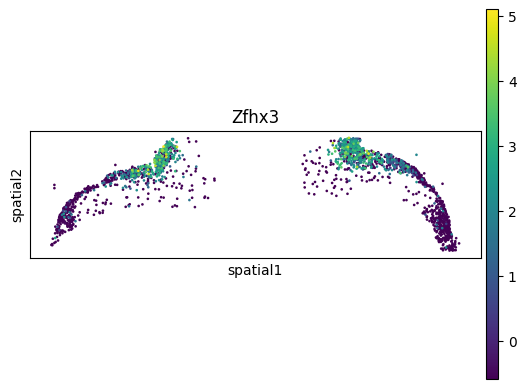

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


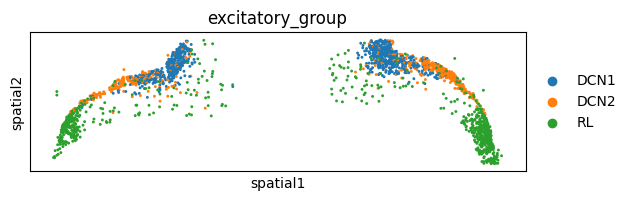

In [30]:
sc.pl.spatial(e11, color = 'Zfhx3', spot_size = 100)
sc.pl.spatial(e11, color = 'excitatory_group', spot_size = 100)

Query expression source: logcounts
Target expression source: lognorm
1699 shared genes

Query groups:


Int/Lat Prog              53
Midbrain-fated Cells    7046
RL                       828
Name: n_cells, dtype: int64


Target groups:


DCN1    661
DCN2    457
RL      669
Name: n_cells, dtype: int64


Shared variable genes: 39
['Actb', 'Atoh1', 'Cd24a', 'Crmp1', 'Dcx', 'Dll1', 'Dpysl2', 'Dpysl3', 'Evx1', 'Fscn1', 'Hes5', 'Hey1', 'Hspd1', 'Lhx2', 'Lhx9', 'Mdk', 'Meis1', 'Myt1', 'Ncam1', 'Nell2', 'Nes', 'Nfia', 'Nr2f2', 'Nr4a2', 'Nrcam', 'Onecut2', 'Pdzrn3', 'Rgmb', 'Robo1', 'Robo2', 'Skil', 'Slit2', 'Sox11', 'Srgap3', 'Stmn1', 'Tubb3', 'Vim', 'Ybx1', 'Zfhx3']

Target cells used: 1787
Genes used: 39


,DCN1,DCN2,RL
Midbrain-fated Cells,0.519298,0.609214,0.391967
Int/Lat Prog,0.244726,0.623143,0.654036
RL,0.218288,0.358833,0.895309


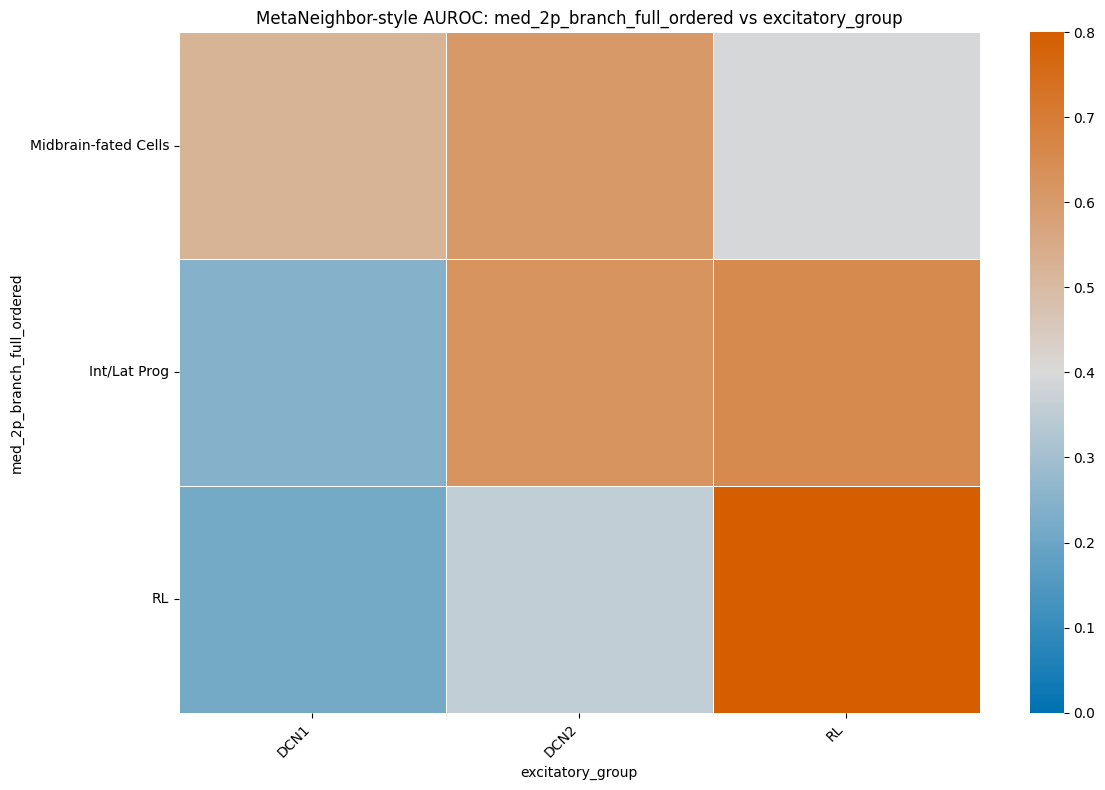

In [31]:
from matplotlib.colors import LinearSegmentedColormap

blue_gray_orange = LinearSegmentedColormap.from_list(
    "blue_gray_orange",
    [
        (0.0, "#0072B2"),   # blue
        (0.5, "#D9D9D9"),   # light gray
        (1.0, "#D55E00"),   # vermillion/orange
    ]
)

x_order = [
    "DCN1",
    "DCN2",
    "RL"
]

y_order = [
    "Midbrain-fated Cells",
    "Int/Lat Prog",
    "RL"
]


auroc, variable_genes, URL_n, e11_n = metaneighbor_style_auroc(
    query_adata=URL_e11,
    target_adata=e11,
    query_groupby="med_2p_branch_full_ordered",
    target_groupby="excitatory_group",
    min_cells=10,
    n_variable_genes=100,
    query_layer="logcounts",
    target_layer="lognorm",
    correlation_method="spearman",
    cmap=blue_gray_orange,
    vmin=0,
    vmax=0.8,
    x_order=x_order,
    y_order=y_order,
    figsize=(12, 8),
    save_prefix="metaneighbor_style_AUROC_URL_vs_e11",
)

In [46]:
del URL_e11
del e11

In [24]:
URL_e12 = URL[URL.obs['TimePoint'] == "E12.5"]
e12 = sc.read_h5ad("adata_scrnaseq_correlations/e12_slice.h5ad")

Query expression source: logcounts
Target expression source: lognorm
1713 shared genes

Query groups:


Early Medial             140
Granule Cells+UBCs        10
Int/Lat Prog            2073
IntA/Lat                  65
IntP                      21
Midbrain-fated Cells    6077
RL                      2424
Name: n_cells, dtype: int64


Target groups:


DCN1     631
DCN2     820
RL      1734
Name: n_cells, dtype: int64


Shared variable genes: 25
['Adcyap1r1', 'Ank3', 'App', 'Cd24a', 'Chn1', 'Cnr1', 'Crmp1', 'Dcx', 'Dpysl2', 'Dpysl3', 'Irx3', 'Mdk', 'Meis1', 'Meis2', 'Ncam1', 'Nell2', 'Nes', 'Nrcam', 'Rgmb', 'Slc17a6', 'Sox11', 'Stmn1', 'Tubb3', 'Vim', 'Zfhx3']

Target cells used: 3185
Genes used: 25


,DCN1,DCN2,RL
Midbrain-fated Cells,0.631466,0.606976,0.326650
Int/Lat Prog,0.453488,0.616790,0.437719
RL,0.359890,0.480402,0.609279


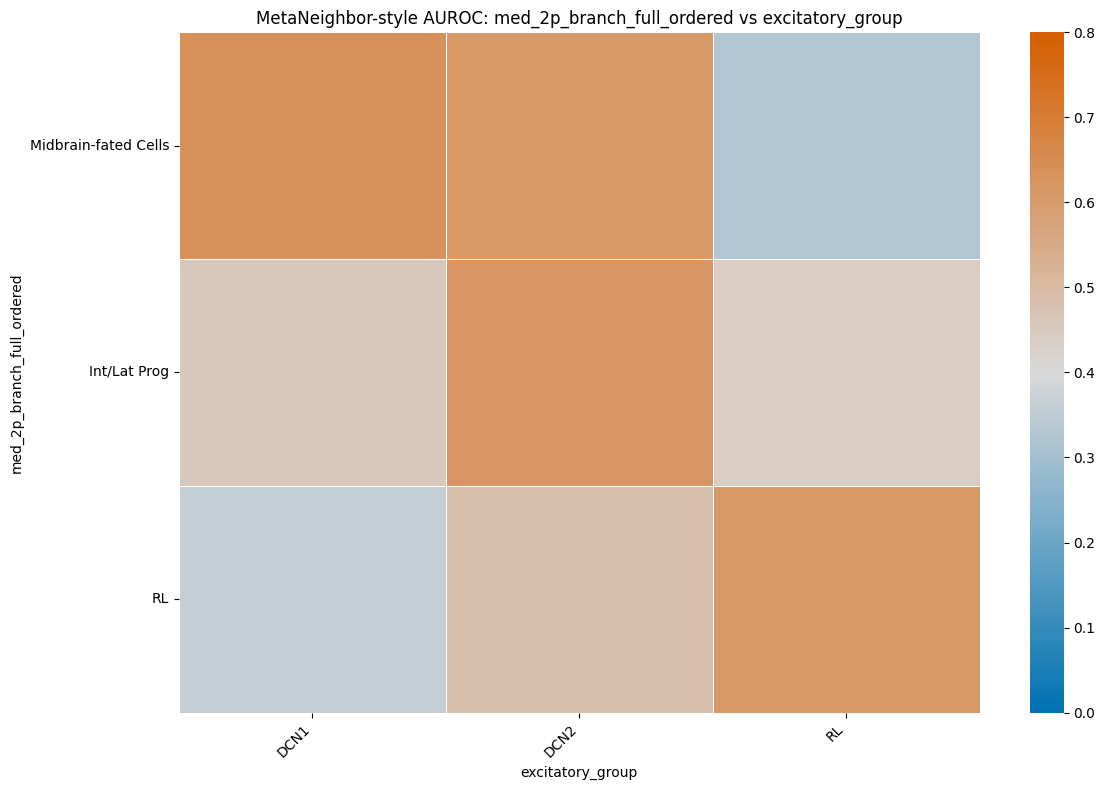

In [26]:
x_order = [
    "DCN1",
    "DCN2",
    "RL"
]

y_order = [
    "Midbrain-fated Cells",
    "Int/Lat Prog",
    "RL"
]

auroc, variable_genes, URL_n, e11_n = metaneighbor_style_auroc(
    query_adata=URL_e12,
    target_adata=e12,
    query_groupby="med_2p_branch_full_ordered",
    target_groupby="excitatory_group",
    min_cells=10,
    n_variable_genes=100,
    query_layer="logcounts",
    target_layer="lognorm",
    correlation_method="spearman",
    cmap=blue_gray_orange,
    vmin=0,
    vmax=0.8,
    x_order=x_order,
    y_order=y_order,
    figsize=(12, 8),
    save_prefix="metaneighbor_style_AUROC_URL_vs_e12",
)

In [27]:
del URL_e12
del e12

In [57]:
URL_e13 = URL[URL.obs['TimePoint'] == "E13.5"]
URL_e13 = URL_e13[URL_e13.obs['med_2p_branch_full_ordered'] != "Granule Cells+UBCs"]

e13 = sc.read_h5ad("adata_scrnaseq_correlations/e13_slice.h5ad")

In [58]:
np.unique(URL_e13.obs["med_2p_branch_full_ordered"])

array(['Early Medial', 'Int/Lat Prog', 'IntA', 'IntA/Lat', 'IntP', 'Lat',
       'Late Medial', 'Midbrain-fated Cells', 'RL'], dtype=object)

Query expression source: logcounts
Target expression source: lognorm
1724 shared genes

Query groups:


Early Medial             670
Int/Lat Prog             355
IntA                      37
IntA/Lat                 498
IntP                     382
Late Medial              961
Midbrain-fated Cells    3210
RL                      2913
Name: n_cells, dtype: int64


Target groups:


DCN1     13
DCN3     77
DCN4    368
DCN5    310
RL      626
Name: n_cells, dtype: int64


Shared variable genes: 227
['Actb', 'Actr3', 'Adgrl2', 'Adgrl3', 'Afdn', 'Agrn', 'Amotl1', 'Angpt1', 'Apc', 'Arhgdia', 'Arid1a', 'Arid2', 'Arpc2', 'Atoh1', 'Barhl1', 'Bbx', 'Bcl11a', 'Bmpr1a', 'Bsg', 'Bzw1', 'Calb2', 'Calr', 'Casp3', 'Ccnd1', 'Cd24a', 'Cdc42', 'Cdh2', 'Celsr1', 'Cfl1', 'Chst15', 'Cib1', 'Cited2', 'Clstn1', 'Crmp1', 'Csk', 'Ctnnb1', 'Ctnnd2', 'Ctsl', 'Cttn', 'Cxcr4', 'Dbn1', 'Dcc', 'Dcx', 'Dennd6a', 'Diaph2', 'Dll1', 'Dnajc1', 'Dpysl2', 'Dpysl3', 'Dusp1', 'E2f1', 'E2f5', 'Ebf1', 'Ebf2', 'Ebf3', 'Efna5', 'Efnb1', 'En2', 'Enah', 'Ep400', 'Epha5', 'Epha7', 'Ephb1', 'Ephb2', 'Evx1', 'Ezh2', 'Fat1', 'Fgfr1', 'Flna', 'Flot1', 'Flrt2', 'Fn1', 'Foxp1', 'Fscn1', 'Fyn', 'Gsk3b', 'Hdac2', 'Hes5', 'Hes6', 'Hey1', 'Hif1a', 'Hivep2', 'Hmgb1', 'Hmgb2', 'Hspd1', 'Ift20', 'Igf1r', 'Ikzf5', 'Irx2', 'Irx3', 'Jund', 'Kif3a', 'Kras', 'Lhx2', 'Lhx9', 'Lima1', 'Limk1', 'Lmx1a', 'Lrp1', 'Mad2l2', 'Maf', 'Map2k2', 'Map4k4', 'Map6', 'Marcks', 'Mdk', 'Meis1', 'Meis2', 'Mllt10', 'Mta1', 'Mxd4', '

,DCN1,DCN5,DCN4,DCN3,RL
Midbrain-fated Cells,0.671014,0.744930,0.573966,0.429479,0.279057
IntA/Lat,0.551951,0.752745,0.639332,0.535852,0.204219
IntP,0.513935,0.700173,0.699260,0.457170,0.211927
Int/Lat Prog,0.414660,0.725267,0.687314,0.450144,0.208956
Early Medial,0.409142,0.709359,0.652203,0.510026,0.235240
RL,0.445429,0.491910,0.389857,0.215944,0.654219


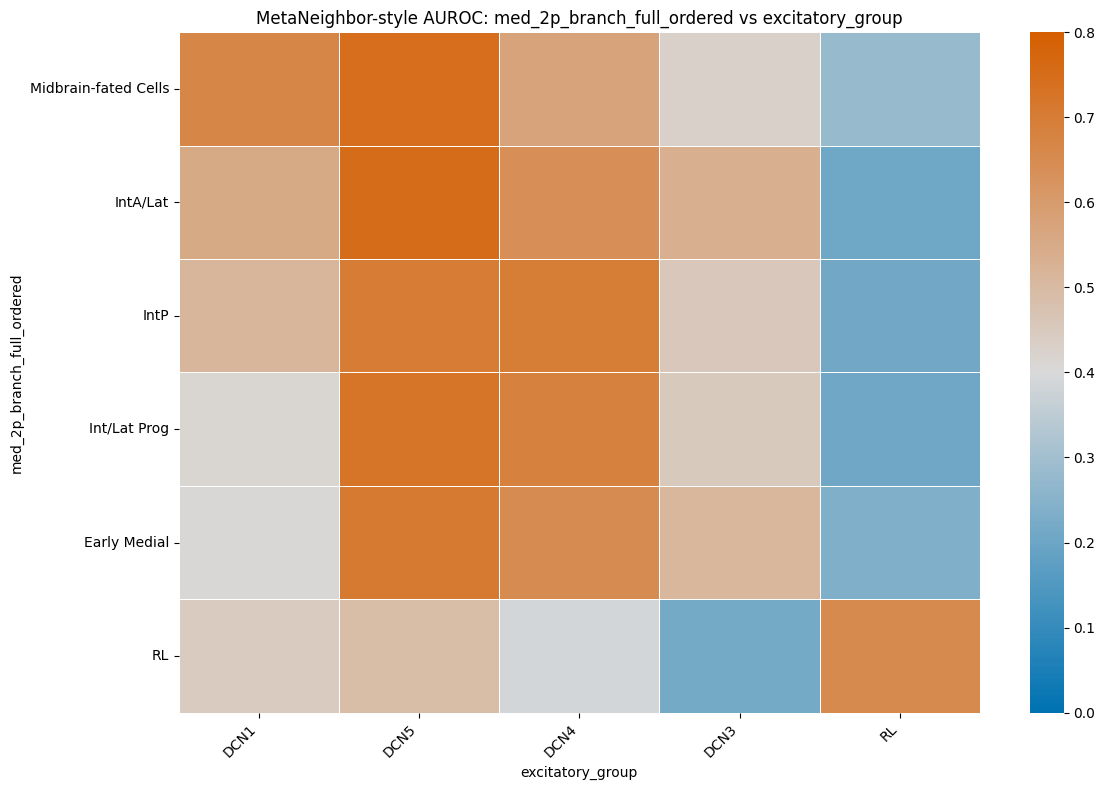

In [59]:
x_order = [
    "DCN1",
    "DCN5",
    "DCN4",
    "DCN3",
    "RL"
]

y_order = [
    "Midbrain-fated Cells",
    "IntA/Lat",
    "IntP",
    "Int/Lat Prog",
    "Early Medial", 
    "RL"
]


auroc, variable_genes, URL_n, e11_n = metaneighbor_style_auroc(
    query_adata=URL_e13,
    target_adata=e13,
    query_groupby="med_2p_branch_full_ordered",
    target_groupby="excitatory_group",
    min_cells=10,
    n_variable_genes=500,
    query_layer="logcounts",
    target_layer="lognorm",
    correlation_method="spearman",
    cmap=blue_gray_orange,
    vmin=0,
    vmax=0.8,
    x_order=x_order,
    y_order=y_order,
    figsize=(12, 8),
    save_prefix="metaneighbor_style_AUROC_URL_vs_e13",
)

In [60]:
del URL_e13
del e13

In [61]:
URL_e13 = URL[URL.obs['TimePoint'] == "E13.5"]
e13_5 = sc.read_h5ad("adata_scrnaseq_correlations/e13_5_slice.h5ad")

Query expression source: logcounts
Target expression source: lognorm
1724 shared genes

Query groups:


Early Medial             670
Granule Cells+UBCs      1080
Int/Lat Prog             355
IntA                      37
IntA/Lat                 498
IntP                     382
Late Medial              961
Midbrain-fated Cells    3210
RL                      2913
Name: n_cells, dtype: int64


Target groups:


DCN1    3334
DCN3     152
DCN4     579
DCN5     425
DCN6     215
RL       287
Name: n_cells, dtype: int64


Shared variable genes: 112
['Actb', 'Adgrl2', 'Afdn', 'Apc', 'Arhgdia', 'Arpc2', 'Bcl11a', 'Bptf', 'Calb2', 'Calm1', 'Calr', 'Cd24a', 'Cdc42', 'Cdh2', 'Cdh4', 'Cfl1', 'Chl1', 'Cited2', 'Clstn1', 'Cnr1', 'Csk', 'Ctnnd2', 'Cxcr4', 'Dbn1', 'Dcc', 'Dcx', 'Dpysl2', 'Dpysl3', 'Efna5', 'En1', 'En2', 'Eomes', 'Ephb1', 'Esrrg', 'Fgfr2', 'Flna', 'Foxn3', 'Fscn1', 'Fyn', 'Gfra1', 'Gsk3b', 'Hdac2', 'Hspd1', 'Irx3', 'Itgb1', 'Kifap3', 'Lhx2', 'Lmo3', 'Lmo4', 'Lmx1a', 'Mad2l2', 'Map6', 'Mdk', 'Meis1', 'Meis2', 'Myt1l', 'Ncam1', 'Nell2', 'Nes', 'Neurod6', 'Nhlh1', 'Nr2f2', 'Nrcam', 'Nrp1', 'Ntng1', 'Ntrk2', 'Ntrk3', 'Numbl', 'Olig2', 'Pak1', 'Palm', 'Pax5', 'Pax6', 'Pcdh9', 'Pdzrn3', 'Pik3r1', 'Plxna2', 'Plxna4', 'Pou3f2', 'Ppia', 'Ptn', 'Rac3', 'Rack1', 'Rcan2', 'Reln', 'Rgmb', 'Robo1', 'Robo2', 'Robo3', 'Rtn4', 'S100a10', 'Sdcbp', 'Sema7a', 'Shtn1', 'Skil', 'Slc17a6', 'Slit2', 'Smad7', 'Sox11', 'Spock1', 'Sptbn1', 'Srgap1', 'Stmn1', 'Tbr1', 'Tenm2', 'Tln1', 'Tubb3', 'Vim', 'Ybx1', 'Zfhx3', 'Zfp462

,DCN1,DCN5,DCN4,DCN3,DCN6,RL
Midbrain-fated Cells,0.626445,0.309737,0.513247,0.491143,0.387181,0.321433
IntA/Lat,0.411582,0.530089,0.717643,0.515382,0.554371,0.357137
IntP,0.415646,0.439503,0.762300,0.510627,0.568403,0.378128
Int/Lat Prog,0.451105,0.404917,0.687977,0.508497,0.523712,0.458471
Early Medial,0.397562,0.401505,0.662927,0.543590,0.673964,0.596564
Late Medial,0.400950,0.371955,0.616088,0.539576,0.695654,0.699489
RL,0.422768,0.396790,0.570831,0.507838,0.573975,0.769953


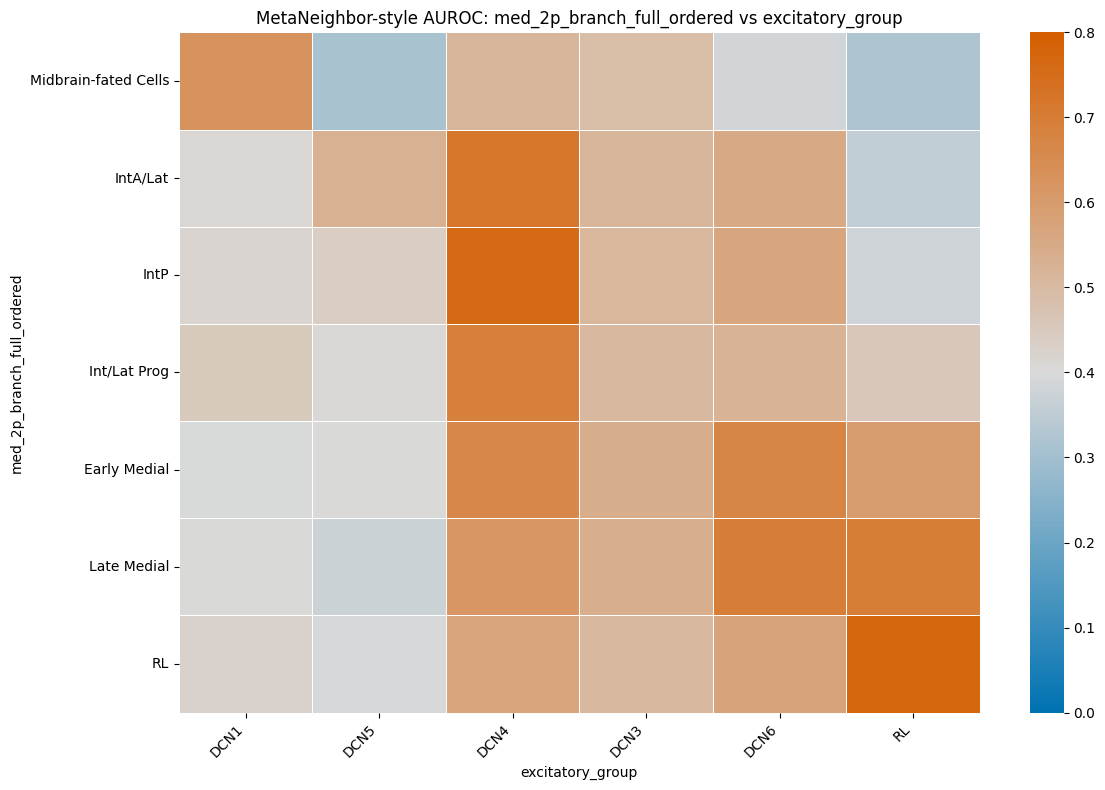

In [62]:
x_order = [
    "DCN1",
    "DCN5",
    "DCN4",
    "DCN3",
    "DCN6",
    "RL"
]

y_order = [
    "Midbrain-fated Cells",
    "IntA/Lat",
    "IntP",
    "Int/Lat Prog",
    "Early Medial", 
    "Late Medial",
    "RL"
]


auroc, variable_genes, URL_n, e11_n = metaneighbor_style_auroc(
    query_adata=URL_e13,
    target_adata=e13_5,
    query_groupby="med_2p_branch_full_ordered",
    target_groupby="excitatory_group",
    min_cells=10,
    n_variable_genes=300,
    query_layer="logcounts",
    target_layer="lognorm",
    correlation_method="spearman",
    cmap=blue_gray_orange,
    vmin=0,
    vmax=0.8,
    x_order=x_order,
    y_order=y_order,
    figsize=(12, 8),
    save_prefix="metaneighbor_style_AUROC_URL_vs_e13_5",
)

In [63]:
del URL_e13
del e13_5

In [8]:
URL_e14 = URL[URL.obs['TimePoint'] == "E14.5"]
e14 = sc.read_h5ad("adata_scrnaseq_correlations/e14_slice.h5ad")
e14.obsm['spatial'][:,1] = np.max(e14.obsm['spatial'][:,1]) - e14.obsm['spatial'][:,1]

Query expression source: logcounts
Target expression source: lognorm
1723 shared genes

Query groups:


Early Medial             441
Granule Cells+UBCs      2567
Int/Lat Prog              38
IntA                     165
IntA/Lat                 252
IntP                     390
Lat                       19
Late Medial              437
Midbrain-fated Cells    2397
RL                      1815
Name: n_cells, dtype: int64


Target groups:


DCN3    1060
DCN4     976
DCN5     791
DCN6     678
Name: n_cells, dtype: int64


Shared variable genes: 80
['Actb', 'Adgrg1', 'Adgrl2', 'Adgrl3', 'Alcam', 'Ank3', 'Apc', 'App', 'Atf4', 'Barhl1', 'Cadm1', 'Calb2', 'Calm1', 'Cd24a', 'Cdc42', 'Cfl1', 'Chl1', 'Cited2', 'Cnr1', 'Crmp1', 'Dpysl2', 'Dpysl3', 'Ebf3', 'Efna5', 'En1', 'Eomes', 'Epha7', 'Ephb1', 'Foxp1', 'Gria2', 'Hmgb1', 'Hrk', 'Hspd1', 'L1cam', 'Lhx9', 'Lmo3', 'Lmo4', 'Lmx1a', 'Macf1', 'Mdga1', 'Mdga2', 'Meis1', 'Meis2', 'Myt1l', 'Ncam1', 'Nell2', 'Nrcam', 'Nrp1', 'Ntng1', 'Olig2', 'Pak1', 'Pax5', 'Pax6', 'Pcdh10', 'Pcdh17', 'Pcdh19', 'Pcdh7', 'Pcdh9', 'Pik3r1', 'Plxna2', 'Pou3f2', 'Ptn', 'Ptprs', 'Rac3', 'Rack1', 'Rcan2', 'Reln', 'Rgmb', 'Robo1', 'Robo2', 'S100a10', 'Slc17a6', 'Sox11', 'Spock1', 'Sptbn1', 'Stmn1', 'Tbr1', 'Tenm2', 'Thra', 'Ybx1']

Target cells used: 3505
Genes used: 80
x_order groups not found and omitted: ['DCN1', 'RL']


,DCN5,DCN4,DCN3,DCN6
IntA/Lat,0.591302,0.664556,0.243790,0.532264
IntP,0.552565,0.698140,0.238695,0.539292
Early Medial,0.425857,0.303722,0.651553,0.630881
Late Medial,0.428373,0.341120,0.615890,0.628125


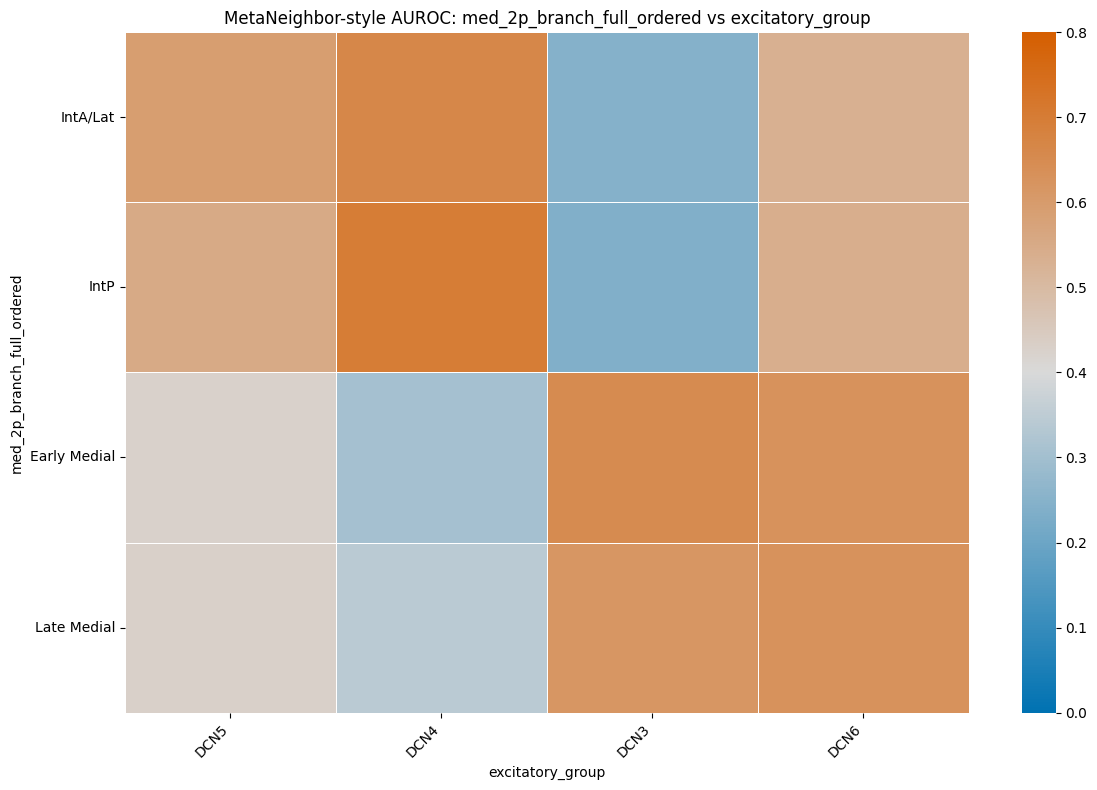

In [14]:
x_order = [
    "DCN1",
    "DCN5",
    "DCN4",
    "DCN3",
    "DCN6",
    "RL"
]

y_order = [
    #"Midbrain-fated Cells",
    "IntA/Lat",
    "IntP",
    #"Int/Lat Prog",
    "Early Medial", 
    "Late Medial"
    #"RL"
]


auroc, variable_genes, URL_n, e11_n = metaneighbor_style_auroc(
    query_adata=URL_e14,
    target_adata=e14,
    query_groupby="med_2p_branch_full_ordered",
    target_groupby="excitatory_group",
    min_cells=10,
    n_variable_genes=200,
    query_layer="logcounts",
    target_layer="lognorm",
    correlation_method="spearman",
    cmap=blue_gray_orange,
    vmin=0,
    vmax=0.8,
    x_order=x_order,
    y_order=y_order,
    figsize=(12, 8),
    save_prefix="metaneighbor_style_AUROC_URL_vs_e14",
)

In [15]:
del URL_e14
del e14

In [17]:
URL_e15 = URL[URL.obs['TimePoint'] == "E16.5"]
e15 = sc.read_h5ad("adata_scrnaseq_correlations/e15_slice.h5ad")
e15.obsm['spatial'][:,1] = np.max(e15.obsm['spatial'][:,1]) - e15.obsm['spatial'][:,1]

In [18]:
e15.var_names

Index(['0610010K14Rik', 'AU041133', 'Abl1', 'Abl2', 'Ache', 'Actb', 'Actn4',
       'Actr3', 'Acvr1', 'Acvrl1',
       ...
       'Zxdc', 'Zzz3', 'no_gene_23', 'no_gene_24', 'no_gene_25', 'no_gene_26',
       'no_gene_27', 'no_gene_28', 'no_gene_29', 'no_gene_30'],
      dtype='object', length=1752)

Query expression source: .X
Target expression source: .X
1724 shared genes

Query groups:


Early Medial               14
Granule Cells+UBCs      11092
IntA                      161
IntP                      105
Lat                        80
Late Medial               122
Midbrain-fated Cells      660
RL                       1197
Name: n_cells, dtype: int64


Target groups:


DCN3     480
DCN4     454
DCN51    359
DCN52     62
DCN6     410
Name: n_cells, dtype: int64


Shared variable genes: 223
['Actb', 'Adcy1', 'Adgrl2', 'Adgrl3', 'Afdn', 'Agrn', 'Akap5', 'Alcam', 'Ank3', 'Anks1b', 'Apc', 'App', 'Arf1', 'Arf4', 'Arfrp1', 'Arhgap35', 'Arid1a', 'Atf2', 'Baz2b', 'Bdp1', 'Bptf', 'Bsg', 'Bzw1', 'Cadm1', 'Calb2', 'Calm1', 'Camsap3', 'Capn2', 'Casp3', 'Cbl', 'Cbll1', 'Cd24a', 'Cdc42', 'Cdh12', 'Cdh4', 'Cdh6', 'Cdh8', 'Cdk4', 'Cdk5r1', 'Cebpz', 'Cfl1', 'Chl1', 'Chn1', 'Cited2', 'Clstn1', 'Clstn3', 'Cnr1', 'Cplx1', 'Crmp1', 'Ctcf', 'Ctnnd2', 'Cxcr4', 'Dab1', 'Deaf1', 'Diaph1', 'Dmap1', 'Dpysl2', 'Dpysl3', 'Dzip1', 'Ebf3', 'Efna5', 'Efnb3', 'En2', 'Enah', 'Eomes', 'Epb41l3', 'Epha10', 'Epha5', 'Epha7', 'Ephb1', 'Esrrg', 'Fbxo45', 'Flna', 'Foxk2', 'Foxn3', 'Foxp1', 'Fyn', 'Fzd3', 'Fzr1', 'Gas6', 'Git1', 'Gon4l', 'Gria2', 'Gsk3b', 'Hey1', 'Hivep3', 'Hmg20a', 'Hmgb1', 'Hmgb3', 'Hrk', 'Ift20', 'Irx1', 'Irx3', 'Jup', 'Kdm1a', 'Kif3a', 'Kit', 'Klf7', 'Kras', 'L1cam', 'Lhx9', 'Lmo3', 'Lmo4', 'Lmx1a', 'Maf', 'Magi2', 'Map4k4', 'Map6', 'Mapk3', 'Mapk8', 'Maz', 'Mdga

,DCN51,DCN52,DCN4,DCN3,DCN6
Lat,0.667178,0.591253,0.557732,0.379100,0.403142
IntA,0.640510,0.660940,0.619957,0.353153,0.376269
IntP,0.498567,0.593867,0.582705,0.410999,0.493669
Early Medial,0.437617,0.573618,0.436605,0.508493,0.601177
Late Medial,0.389326,0.552479,0.410092,0.546536,0.635237


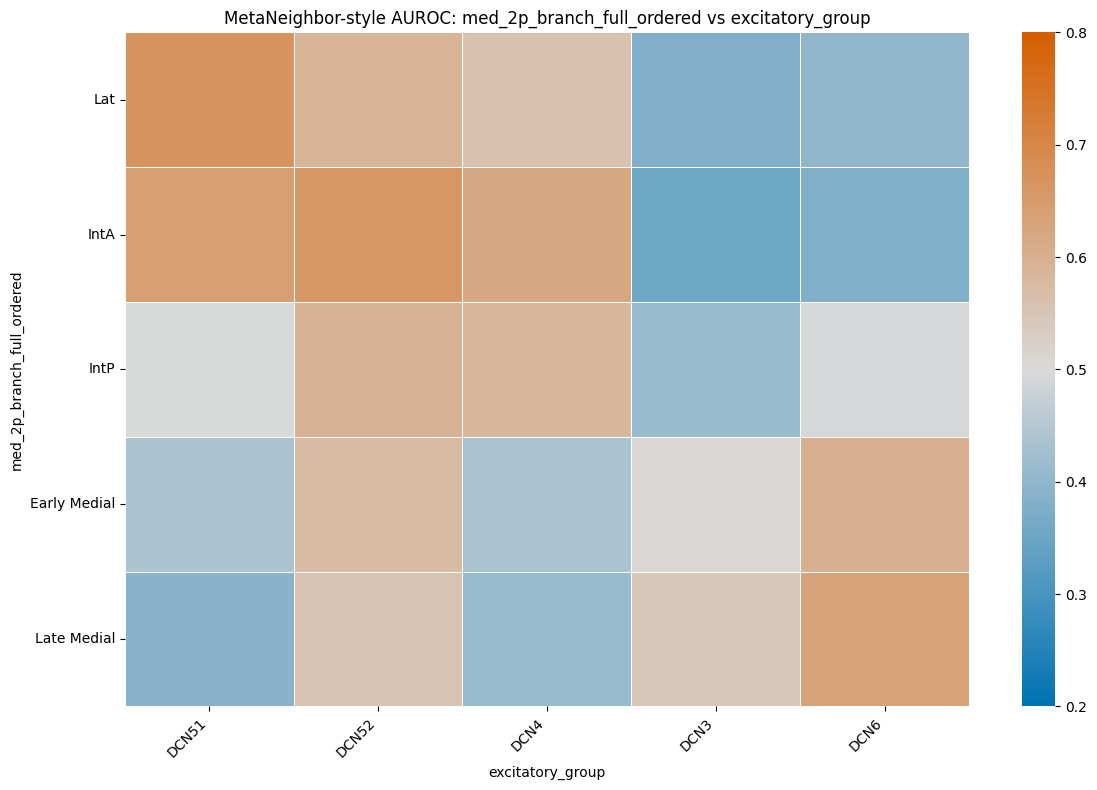

In [20]:
x_order = [
    "DCN51",
    "DCN52",
    "DCN4",
    "DCN3",
    "DCN6",
   
]

y_order = [
    #"Midbrain-fated Cells",
    "IntA/Lat",
    "Lat",
    "IntA",
    "IntP",
    #"Int/Lat Prog",
    "Early Medial", 
    "Late Medial",
    #"RL"
]


auroc, variable_genes, URL_n, e11_n = metaneighbor_style_auroc(
    query_adata=URL_e15,
    target_adata=e15,
    query_groupby="med_2p_branch_full_ordered",
    target_groupby="excitatory_group",
    min_cells=10,
    n_variable_genes=500,
    #query_layer="logcounts",
    #target_layer="lognorm",
    correlation_method="spearman",
    cmap=blue_gray_orange,
    vmin=0.2,
    vmax=0.8,
    x_order=x_order,
    y_order=y_order,
    figsize=(12, 8),
    save_prefix="metaneighbor_style_AUROC_URL_vs_e15",
)

In [6]:
np.unique(URL.obs['TimePoint'])

array(['E10.5', 'E11.5', 'E12.5', 'E13.5', 'E14.5', 'E16.5', 'E9.5'],
      dtype=object)

In [8]:
URL_e17 = URL[URL.obs['TimePoint']=="E16.5"]
e17 = sc.read_h5ad("adata_scrnaseq_correlations/e17_slice.h5ad")
e17.obsm['spatial'][:,1] = np.max(e17.obsm['spatial'][:,1]) - e17.obsm['spatial'][:,1]

Query expression source: .X
Target expression source: .X
1723 shared genes

Query groups:


Early Medial               14
Granule Cells+UBCs      11092
IntA                      161
IntP                      105
Lat                        80
Late Medial               122
Midbrain-fated Cells      660
RL                       1197
Name: n_cells, dtype: int64


Target groups:


DCN3     424
DCN4     749
DCN51    504
DCN52     35
DCN6     308
Name: n_cells, dtype: int64


Shared variable genes: 175
['Adcy1', 'Add2', 'Adgrl2', 'Afdn', 'Agrn', 'Akt3', 'Ank3', 'Apc', 'App', 'Arhgap35', 'Arid1a', 'Arnt2', 'Arpc2', 'Atf4', 'B3gat1', 'Bcl11a', 'Bptf', 'Bzw1', 'Cadm1', 'Calb2', 'Calm1', 'Capn2', 'Cbll1', 'Cd200', 'Cd24a', 'Cdc42', 'Cdh12', 'Cdh4', 'Cdh6', 'Cdh8', 'Cdk4', 'Chd7', 'Chl1', 'Cited2', 'Clstn1', 'Clstn3', 'Crmp1', 'Csde1', 'Csk', 'Ctnnb1', 'Ctnnd2', 'Cxadr', 'Dab1', 'Dbn1', 'Dcx', 'Deaf1', 'Diaph1', 'Dnmt1', 'Dpysl3', 'Efnb3', 'Ep400', 'Epb41l3', 'Epha7', 'Ephb1', 'Ephb2', 'Esrrb', 'Esrrg', 'Flna', 'Flrt3', 'Foxn3', 'Fzr1', 'Gabbr2', 'Gon4l', 'Hbegf', 'Hes6', 'Hivep1', 'Hivep3', 'Hmgb2', 'Hmgb3', 'Hmgn3', 'Igf1r', 'Irx2', 'Irx3', 'Klf7', 'L1cam', 'Lhx9', 'Lmo1', 'Lmo3', 'Lmx1a', 'Map6', 'Mapk8', 'Mdga1', 'Mef2a', 'Meis2', 'Mgat3', 'Myc', 'Mycn', 'Ncam1', 'Nck1', 'Neurod2', 'Neurod6', 'Nexmif', 'Nfe2l1', 'Nfix', 'Nhlh2', 'Nlgn1', 'Nr2c2', 'Nr2f1', 'Nrcam', 'Nrp1', 'Nrp2', 'Ntng1', 'Ntrk2', 'Olig1', 'Olig2', 'Palm', 'Parp1', 'Pax3', 'Pax5', 'Pbx4', '

,DCN51,DCN52,DCN4,DCN3,DCN6
Lat,0.627678,0.480734,0.458173,0.437705,0.472991
IntA,0.587423,0.526261,0.523029,0.413596,0.439173
IntP,0.541321,0.427974,0.503613,0.505481,0.436058
Early Medial,0.469953,0.397481,0.393175,0.637949,0.572872
Late Medial,0.458409,0.369601,0.369565,0.662710,0.604121


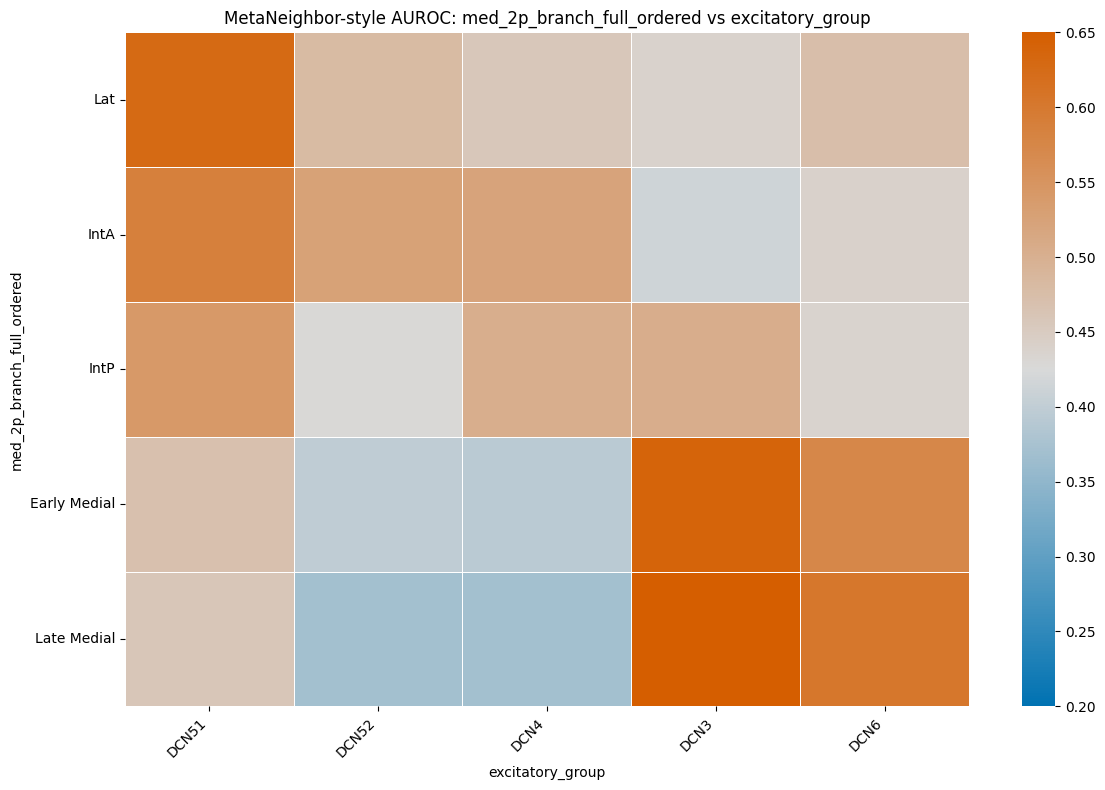

In [16]:
x_order = [
    "DCN51",
    "DCN52",
    "DCN4",
    "DCN3",
    "DCN6",
   
]

y_order = [
    #"Midbrain-fated Cells",
    "IntA/Lat",
    "Lat",
    "IntA",
    "IntP",
    #"Int/Lat Prog",
    "Early Medial", 
    "Late Medial",
    #"RL"
]


auroc, variable_genes, URL_n, e11_n = metaneighbor_style_auroc(
    query_adata=URL_e17,
    target_adata=e17,
    query_groupby="med_2p_branch_full_ordered",
    target_groupby="excitatory_group",
    min_cells=10,
    n_variable_genes=500,
    #query_layer="logcounts",
    #target_layer="lognorm",
    correlation_method="spearman",
    cmap=blue_gray_orange,
    vmin=0.2,
    vmax=0.65,
    x_order=x_order,
    y_order=y_order,
    figsize=(12, 8),
    save_prefix="metaneighbor_style_AUROC_URL_vs_e17",
)